In [3]:
import pandas as pd

# Step 1: Load data
columns_to_use = ['LEAVE_TIME', 'STOP_TIME', 'GARAGE', 'ROUTE_NUMBER', 'ONS', 'OFFS']
file3 = "/Users/kathypresto/Desktop/trimet/Big_Data/untitled folder 3/trimet_stop_event_2023_2024.csv"
df_2023 = pd.read_csv(file3, usecols=columns_to_use)

# Step 2: Filter to bus-only garages
df_2023 = df_2023[~df_2023['GARAGE'].isin(['RUBY', 'ELMO'])]

# Step 3: Calculate delay + define ON_TIME
df_2023['DELAY_MINUTES'] = (df_2023['LEAVE_TIME'] - df_2023['STOP_TIME']) / 60
df_2023['ON_TIME'] = df_2023['DELAY_MINUTES'].between(-1, 5).astype(int)

# Step 4: Create TIME_BIN from LEAVE_TIME
def map_time_bin(seconds):
    if seconds <= 21600:
        return 'Early'
    elif seconds <= 54000:
        return 'Day'
    elif seconds <= 79200:
        return 'Evening'
    else:
        return 'Late Night'

df_2023['TIME_BIN'] = df_2023['LEAVE_TIME'].apply(map_time_bin)

# Step 5: Create RIDERSHIP and RIDERSHIP_GROUP
df_2023['RIDERSHIP'] = df_2023['ONS'] + df_2023['OFFS']
df_2023['RIDERSHIP_GROUP'] = pd.cut(
    df_2023['RIDERSHIP'],
    bins=[-1, 0, 5, float('inf')],
    labels=['None', 'Low (1–5)', 'Med (6+)']
)

# Step 6: Keep only necessary columns for modeling
df_2023_logit = df_2023[['ON_TIME', 'ROUTE_NUMBER', 'RIDERSHIP_GROUP', 'TIME_BIN', 'GARAGE']]


In [4]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd

# STEP 1: Keep only routes with at least 5,000 records
route_counts = df_2023_logit['ROUTE_NUMBER'].value_counts()
common_routes = route_counts[route_counts > 5000].index
df_filtered = df_2023_logit[df_2023_logit['ROUTE_NUMBER'].isin(common_routes)]

# STEP 2: Sample down to 100k rows for modeling
df_sample = df_filtered.sample(n=100_000, random_state=42)

# STEP 3: One-hot encode
df_encoded = pd.get_dummies(df_sample, columns=['ROUTE_NUMBER', 'RIDERSHIP_GROUP', 'TIME_BIN', 'GARAGE'], drop_first=True)

# STEP 4: Split and model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df_encoded.drop('ON_TIME', axis=1)
y = df_encoded['ON_TIME']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# STEP 5: See what's driving OTP
import pandas as pd
coefficients = pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=False)
print("Top positive influences on OTP:\n", coefficients.head())
print("\nTop negative influences on OTP:\n", coefficients.tail())


Top positive influences on OTP:
 ROUTE_NUMBER_46    0.821914
ROUTE_NUMBER_51    0.632851
ROUTE_NUMBER_85    0.620940
ROUTE_NUMBER_84    0.570714
ROUTE_NUMBER_22    0.487564
dtype: float64

Top negative influences on OTP:
 ROUTE_NUMBER_66    -0.480391
ROUTE_NUMBER_99    -0.677191
ROUTE_NUMBER_96    -0.764793
ROUTE_NUMBER_922   -1.369002
ROUTE_NUMBER_921   -1.820629
dtype: float64


In [8]:
# Reprint all coefficients grouped by variable type
coeff_df = coefficients.reset_index()
coeff_df.columns = ['Feature', 'Coefficient']
coeff_df['Group'] = coeff_df['Feature'].str.extract(r'^(.*?)_')  # Extract prefix

# See average effect per group
print(coeff_df.groupby('Group')['Coefficient'].mean().sort_values(ascending=False))

# Optional: print full table to see all garage/time_bin/etc.
with pd.option_context('display.max_rows', None):
    display(coeff_df.sort_values(by='Coefficient', ascending=False))


Group
TIME         0.066041
ROUTE        0.020552
GARAGE      -0.013710
RIDERSHIP   -0.040067
Name: Coefficient, dtype: float64


,Feature,Coefficient,Group
0,ROUTE_NUMBER_46,0.821914,ROUTE
1,ROUTE_NUMBER_51,0.632851,ROUTE
2,ROUTE_NUMBER_85,0.620940,ROUTE
3,ROUTE_NUMBER_84,0.570714,ROUTE
4,ROUTE_NUMBER_22,0.487564,ROUTE
5,ROUTE_NUMBER_45,0.458628,ROUTE
6,ROUTE_NUMBER_31,0.456060,ROUTE
7,ROUTE_NUMBER_59,0.416572,ROUTE
8,ROUTE_NUMBER_53,0.416522,ROUTE
9,TIME_BIN_Early,0.411000,TIME


In [18]:
import numpy as np

# Convert coefficients to odds ratios
odds_ratios = np.exp(coefficients)

# Combine into a DataFrame for easy viewing
summary = pd.DataFrame({
    'Feature': coefficients.index,
    'Log-Odds Coefficient': coefficients.values,
    'Odds Ratio': odds_ratios
})

# Filter for non-route features
non_route_summary = summary[~summary['Feature'].str.startswith('ROUTE_NUMBER')]
non_route_summary = non_route_summary.sort_values(by='Odds Ratio', ascending=False)

# Clean top/bottom non-route influences (no overlap)
print("\nTop Positive Non-Route Influences (Odds Ratio):\n")
print(non_route_summary[non_route_summary['Log-Odds Coefficient'] > 0].sort_values(by='Odds Ratio', ascending=False).head(3))

print("\nTop Negative Non-Route Influences (Odds Ratio):\n")
print(non_route_summary[non_route_summary['Log-Odds Coefficient'] < 0].sort_values(by='Odds Ratio').head(3))


# Then sort the full summary and show top/bottom
summary = summary.sort_values(by='Log-Odds Coefficient', ascending=False)

print("\nTop Positive Influences (Odds Ratio):\n")
print(summary.head(10))

print("\nTop Negative Influences (Odds Ratio):\n")
print(summary.tail(10))



Top Positive Non-Route Influences (Odds Ratio):

                                             Feature  Log-Odds Coefficient  \
TIME_BIN_Early                        TIME_BIN_Early              0.411000   
RIDERSHIP_GROUP_Low (1–5)  RIDERSHIP_GROUP_Low (1–5)              0.103875   
TIME_BIN_Late Night              TIME_BIN_Late Night              0.051187   

                           Odds Ratio  
TIME_BIN_Early               1.508325  
RIDERSHIP_GROUP_Low (1–5)    1.109462  
TIME_BIN_Late Night          1.052519  

Top Negative Non-Route Influences (Odds Ratio):

                                           Feature  Log-Odds Coefficient  \
TIME_BIN_Evening                  TIME_BIN_Evening             -0.264064   
RIDERSHIP_GROUP_Med (6+)  RIDERSHIP_GROUP_Med (6+)             -0.184008   
GARAGE_MERLO                          GARAGE_MERLO             -0.023872   

                          Odds Ratio  
TIME_BIN_Evening            0.767924  
RIDERSHIP_GROUP_Med (6+)    0.831929  
GARAG

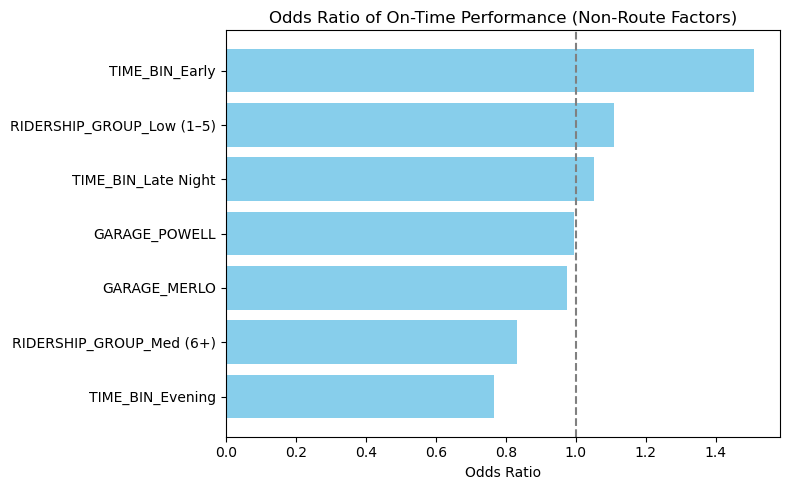

In [20]:
import matplotlib.pyplot as plt

# Filter non-route features only
non_route_plot = non_route_summary.copy()
non_route_plot = non_route_plot.sort_values(by='Odds Ratio', ascending=True)

# Plot
plt.figure(figsize=(8, 5))
plt.barh(non_route_plot['Feature'], non_route_plot['Odds Ratio'], color='skyblue')
plt.axvline(x=1.0, color='gray', linestyle='--')  # 1.0 = neutral
plt.title("Odds Ratio of On-Time Performance (Non-Route Factors)")
plt.xlabel("Odds Ratio")
plt.tight_layout()
plt.show()


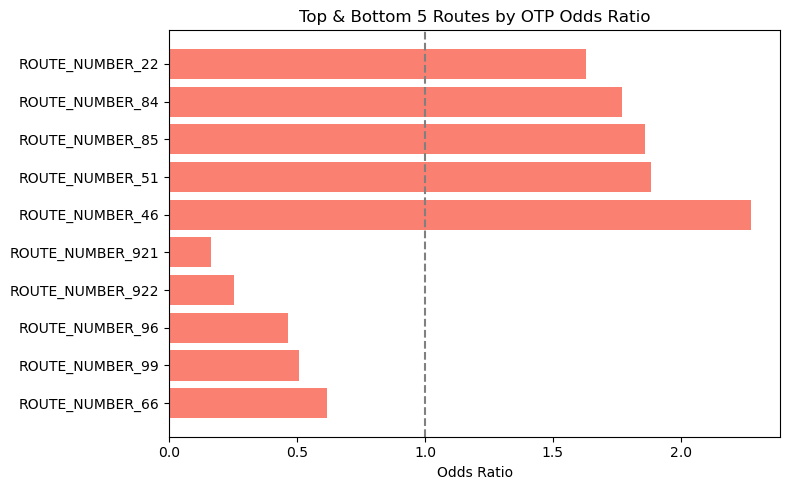

In [22]:
# Filter just route rows
route_summary = summary[summary['Feature'].str.startswith('ROUTE_NUMBER')]

# Get top 5 and bottom 5
top_routes = route_summary.head(5)
bottom_routes = route_summary.tail(5)
routes_plot = pd.concat([bottom_routes, top_routes])

# Plot
plt.figure(figsize=(8, 5))
plt.barh(routes_plot['Feature'], routes_plot['Odds Ratio'], color='salmon')
plt.axvline(x=1.0, color='gray', linestyle='--')
plt.title("Top & Bottom 5 Routes by OTP Odds Ratio")
plt.xlabel("Odds Ratio")
plt.tight_layout()
plt.show()
